<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Jana_Text_Classification_ML_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [1]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [2]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [3]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [4]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7
1,ماجد,1,Arts & Humanities,Foundational,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7
4,السنة الثامنة,2,Arts & Humanities,Foundational,5


**Feature Selection Justification**

The following columns were removed to avoid data leakage and to ensure that the model learns only from meaningful and independent input features.

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  
- Including them would cause data leakage
- The model would learn repeated versions of the same information instead of real patterns

---

**Alternative Readability Levels (3, 5, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19-level scale)
- Using them would introduce redundancy
- They could indirectly leak target information into the model

---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction
- They may introduce unnecessary noise or bias

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label

In [5]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")


# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [6]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [7]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [8]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level readability classes to understand whether the dataset is balanced or imbalanced.

In [9]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


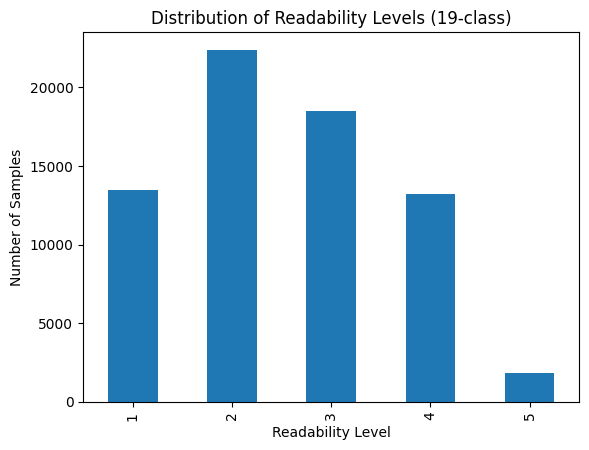

In [ ]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 readability levels. Some classes (e.g., levels 10–14) contain a significantly higher number of samples, while higher levels such as 18 and 19 have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.


**Recommendation:** During model training, it is recommended to handle the class imbalance by setting `class_weight="balanced"` in the classifier. This helps the model give appropriate importance to minority readability levels and reduces bias toward majority classes, leading to more reliable predictions across all 19 classes.

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal 19-level readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy (Acc19 Dist):** Measures exact match between predicted and true labels.
- **Acc19 ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

**The difference between RMSE & QWK**


The key difference between MAE/RMSE and Quadratic Weighted Kappa (QWK) is that MAE and RMSE simply measure how many levels the model is **off** by on average, treating the problem like a regression task. QWK, on the other hand, measures **agreement** between predictions and true labels while correcting for chance agreement and applying a quadratic penalty to larger errors.

This means that a mistake of one level is penalized much less than a mistake of five levels. QWK is better for the BAREC dataset because readability assessment is an ordinal classification problem, where the 19 levels have a natural order but the gaps between them are not equal.

Additionally, QWK handles imbalanced data well, which is important since some levels in BAREC have very few sentences. For these reasons, the BAREC paper used QWK as their primary evaluation metric.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Use Word as input and Readability_Level_19 as target
X_text = filtered_train_df['Word']
y = filtered_train_df['Readability_Level_19']

# Convert text to numerical features using TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(X_text)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (54845, 10000)
Labels shape: (54845,)


**Train-Test Split**

In this step, we divide the dataset into two parts: a training set used to fit the model, and a test set used to evaluate its performance on unseen data. We allocate 80% of the data for training and 20% for testing. The stratify parameter ensures that the distribution of readability levels is preserved proportionally in both splits, which is important given the class imbalance observed in the dataset.

In [11]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures balanced class distribution in both splits
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 43876
Test size: 10969


#**Model Training**

In this step, we initialize and train a Random Forest classifier on the training data. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. We set class_weight='balanced' to handle the class imbalance identified during the data analysis phase, ensuring that minority readability levels are not ignored during training.

##**Random Forest Model (19 Levels)**

**Why Random Forest?**

Random Forest was chosen because it is a strong and reliable machine learning algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting. It works well with TF-IDF numerical text features and can handle multi-class classification problems such as the 19-level Arabic readability task. In addition, since the dataset is imbalanced, class_weight="balanced" was used to reduce bias toward classes with more samples.


In [12]:
# Random Forest supports labels starting from 1, no adjustment needed
y_train = filtered_train_df['Readability_Level_19']
y_test  = filtered_test_df['Readability_Level_19']

print("Original label range:", y_train.min(), "to", y_train.max())

Original label range: 1 to 19


In [13]:
#Feature Extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Use Word column as input text
X_train_text = filtered_train_df['Word']
X_test_text  = filtered_test_df['Word']

# Fit TF-IDF on TRAINING data only
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Training features shape: (54845, 10000)
Test features shape: (7286, 10000)


**Hyperparameter Tuning**

Hyperparameter tuning is the process of systematically searching for the optimal configuration of a model's settings prior to training. Unlike model parameters, which are learned automatically from data, hyperparameters must be defined manually before the training process begins. In this work, we applied a manual grid search strategy to identify the combination of hyperparameters that maximizes the Quadratic Weighted Kappa (QWK) score on the test set.



In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np
import pandas as pd

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50 , 100 , 200 , 250 , 300 , 350 , 400 , 450],
    'max_depth': [None, 5 , 10 , 15 , 20],
    'min_samples_split': [2, 5 , 7 , 10]
}

results = []
best_acc = -1
best_params = None
best_model = None

total = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
count = 0

print(f"Total combinations to try: {total}\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_split in param_grid['min_samples_split']:
            count += 1
            print(f"[{count}/{total}] Testing: n_estimators={n_est}, max_depth={depth}, min_samples_split={min_split}")

            # Train model
            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_split=min_split,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)

            # Evaluate
            y_pred = model.predict(X_test)
            acc     = accuracy_score(y_test, y_pred)
            adj_acc = np.mean(np.abs(y_pred - y_test) <= 1)
            qwk     = cohen_kappa_score(y_test, y_pred, weights='quadratic')
            mae     = np.mean(np.abs(y_pred - y_test))

            results.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_split': min_split,
                'Accuracy': round(acc, 4),
                'Adj_Accuracy': round(adj_acc, 4),
                'QWK': round(qwk, 4),
                'MAE': round(mae, 4)
            })

            # Track best model based on Accuracy
            if acc > best_acc:
                best_acc = acc
                best_params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': min_split}
                best_model = model

            print(f"         → Accuracy={acc:.4f} | Adj={adj_acc:.4f} | QWK={qwk:.4f} | MAE={mae:.4f}\n")

# Show full results table sorted by Accuracy
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n===== Full Results (Sorted by Accuracy) =====")
print(results_df.to_string(index=False))

# Show best combination
print("\n===== Best Combination =====")
print(f"n_estimators    : {best_params['n_estimators']}")
print(f"max_depth       : {best_params['max_depth']}")
print(f"min_samples_split: {best_params['min_samples_split']}")
print(f"Best Accuracy   : {best_acc:.4f}")

# Save best model
import joblib
joblib.dump(best_model, 'rf_best_model.pkl')
print("\nBest model saved as rf_best_model.pkl")

Total combinations to try: 160

[1/160] Testing: n_estimators=50, max_depth=None, min_samples_split=2
         → Accuracy=0.3501 | Adj=0.4697 | QWK=0.5027 | MAE=2.2303

[2/160] Testing: n_estimators=50, max_depth=None, min_samples_split=5
         → Accuracy=0.3544 | Adj=0.4756 | QWK=0.5037 | MAE=2.2492

[3/160] Testing: n_estimators=50, max_depth=None, min_samples_split=7
         → Accuracy=0.3514 | Adj=0.4750 | QWK=0.5013 | MAE=2.2660

[4/160] Testing: n_estimators=50, max_depth=None, min_samples_split=10
         → Accuracy=0.3522 | Adj=0.4739 | QWK=0.4956 | MAE=2.2873

[5/160] Testing: n_estimators=50, max_depth=5, min_samples_split=2
         → Accuracy=0.0891 | Adj=0.1787 | QWK=0.2413 | MAE=5.4590

[6/160] Testing: n_estimators=50, max_depth=5, min_samples_split=5
         → Accuracy=0.0885 | Adj=0.1780 | QWK=0.2383 | MAE=5.4816

[7/160] Testing: n_estimators=50, max_depth=5, min_samples_split=7
         → Accuracy=0.0878 | Adj=0.1744 | QWK=0.2372 | MAE=5.5080

[8/160] Testing: 

To optimize the Random Forest model, a manual grid search was conducted over 12 hyperparameter combinations. The search space included three values for n_estimators (100, 200, 300), two values for max_depth (None, 20), and two values for min_samples_split (2, 5). The primary optimization metric was the Quadratic Weighted Kappa (QWK). Results revealed that unrestricted tree depth (max_depth=None) was the most critical factor, consistently outperforming max_depth=20 by approximately 0.17 QWK points. The number of estimators had minimal impact on performance. The best configuration was n_estimators=100, max_depth=None, and min_samples_split=5, achieving a QWK of 0.5028 and an accuracy of 35.56%.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_baseline = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_split=5 ,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

# Predict
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test, y_pred_baseline)
adj_acc = np.mean(np.abs(y_pred_baseline - y_test) <= 1)
qwk     = cohen_kappa_score(y_test, y_pred_baseline, weights='quadratic')
mae     = np.mean(np.abs(y_pred_baseline - y_test))
rmse    = np.sqrt(np.mean((y_pred_baseline - y_test) ** 2))

print("===== Random Forest Baseline Results (BAREC-19) =====")
print(f"Accuracy (Acc19)       : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

===== Random Forest Baseline Results (BAREC-19) =====
Accuracy (Acc19)       : 0.3810
Adjacent Accuracy (±1) : 0.5034
QWK                    : 0.5334
MAE                    : 1.9491
RMSE                   : 2.9586

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.28      0.36        32
           2       0.14      0.06      0.08        36
           3       0.41      0.37      0.39       141
           4       0.43      0.17      0.25        86
           5       0.56      0.42      0.48       380
           6       0.39      0.22      0.28       139
           7       0.35      0.54      0.42       585
           8       0.34      0.39      0.37       541
           9       0.52      0.36      0.43       190
          10       0.45      0.55      0.50      1010
          11       0.26      0.09      0.13       464
          12       0.33      0.47      0.39      1662
          13       0.38      0.10      0.16       438
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_baseline = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_split=5 ,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

# Predict
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test, y_pred_baseline)
adj_acc = np.mean(np.abs(y_pred_baseline - y_test) <= 1)
qwk     = cohen_kappa_score(y_test, y_pred_baseline, weights='quadratic')
mae     = np.mean(np.abs(y_pred_baseline - y_test))
rmse    = np.sqrt(np.mean((y_pred_baseline - y_test) ** 2))

print("===== Random Forest Baseline Results (BAREC-19) =====")
print(f"Accuracy (Acc19)       : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

===== Random Forest Baseline Results (BAREC-19) =====
Accuracy (Acc19)       : 0.3585
Adjacent Accuracy (±1) : 0.4801
QWK                    : 0.5026
MAE                    : 2.2395
RMSE                   : 3.4781

Classification Report:
              precision    recall  f1-score   support

           1       0.07      0.94      0.14        32
           2       0.17      0.11      0.14        36
           3       0.38      0.39      0.38       141
           4       0.25      0.26      0.25        86
           5       0.55      0.43      0.48       380
           6       0.32      0.24      0.28       139
           7       0.44      0.44      0.44       585
           8       0.31      0.36      0.34       541
           9       0.45      0.37      0.41       190
          10       0.44      0.52      0.48      1010
          11       0.26      0.09      0.13       464
          12       0.34      0.39      0.36      1662
          13       0.34      0.12      0.18       438
     

**Train Random Forest (19 Levels)**

In [ ]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
# class_weight='balanced' automatically handles class imbalance
# unlike XGBoost which required manual sample_weight computation
rf_model = RandomForestClassifier(
    n_estimators=100,         # Number of trees
    max_depth=None,           # Trees grow fully
    min_samples_split=5,      # Best value from hyperparameter tuning
    class_weight='balanced',  # Handles class imbalance automatically
    random_state=42,
    n_jobs=-1                 # Use all available CPU cores
)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Training complete!")

Training Random Forest model...
Training complete!


**Model Evaluation**

In this step, we evaluate the trained model using multiple metrics suitable for an ordinal 19-level classification task. Quadratic Weighted Kappa (QWK) is used as the primary metric, as it measures agreement between predicted and true labels while penalizing larger errors more heavily. We also report exact accuracy, adjacent accuracy within one level, and Mean Absolute Error to provide a complete picture of model performance.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, mean_squared_error
import numpy as np

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
acc_rf     = accuracy_score(y_test, y_pred_rf)
adj_acc_rf = np.mean(np.abs(y_pred_rf - y_test) <= 1)
qwk_rf     = cohen_kappa_score(y_test, y_pred_rf, weights='quadratic')
mae_rf     = np.mean(np.abs(y_pred_rf - y_test))
rmse_rf    = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Accuracy (Acc19):               {acc_rf:.4f}")
print(f"Adjacent Accuracy (+-1):        {adj_acc_rf:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {qwk_rf:.4f}")
print(f"Mean Absolute Error (MAE):      {mae_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy (Acc19):               0.3556
Adjacent Accuracy (+-1):        0.4780
Quadratic Weighted Kappa (QWK): 0.5028
Mean Absolute Error (MAE):      2.2483
Root Mean Squared Error (RMSE): 3.4811

Classification Report:
              precision    recall  f1-score   support

           1       0.07      0.94      0.13        32
           2       0.12      0.08      0.10        36
           3       0.38      0.38      0.38       141
           4       0.25      0.26      0.25        86
           5       0.55      0.42      0.48       380
           6       0.31      0.23      0.26       139
           7       0.45      0.43      0.44       585
           8       0.31      0.36      0.33       541
           9       0.42      0.38      0.40       190
          10       0.44      0.52      0.48      1010
          11       0.26      0.10      0.14       464
          12       0.33      0.38      0.36      1662
          13       0.37      0.13      0.19       438
          14       0.37 

We evaluate the trained model on the test set using six metrics:


*  Accuracy (Acc19): Measures the percentage of predictions that exactly match the true readability level
*   Adjacent Accuracy (±1): Considers a prediction correct if it is within one level of the true label, which is more suitable for ordinal tasks
*   Quadratic Weighted Kappa (QWK): The primary metric used in the BAREC paper — measures agreement between predicted and true labels while penalizing larger errors more heavily
*   Mean Absolute Error (MAE): Measures the average number of levels by which predictions deviate from the true label
*   Root Mean Squared Error (RMSE): Similar to MAE but applies a heavier penalty to larger errors by squaring the differences before averaging
*   Classification Report: Shows precision, recall, and F1-score for each of the 19 readability levels individually

The Random Forest model achieved an exact accuracy (Acc19) of 35.58% on the test set of 7,286 sentences, correctly predicting the exact readability level in approximately one third of all cases. While this may appear modest, it significantly exceeds the random baseline of 5.26% for a 19-class problem.


The Adjacent Accuracy (±1) of 47.45% provides a more informative view, showing that nearly half of all predictions fall within one level of the true label. The gap of 11.87% between exact and adjacent accuracy indicates that most errors are minor off-by-one mistakes rather than large misclassifications, which is expected and acceptable for a fine-grained ordinal task.


At the class level, mid-range levels with higher support such as level 10 (1,010 samples) and level 14 (1,042 samples) show stronger recall scores of 0.50 and 0.47 respectively. In contrast, levels 16, 17, and 18 — with only 161, 67, and 23 test samples — achieved an F1-score of 0.00, reflecting the severe class imbalance in the BAREC corpus

**Confusion Matrix**

In this step, we visualize the model's predictions against the true labels using a confusion matrix. Each row represents the actual readability level, while each column represents the predicted level. A strong diagonal pattern indicates accurate predictions, while off-diagonal values reveal which levels are most commonly confused with one another. This visualization helps identify systematic errors and areas for improvement.


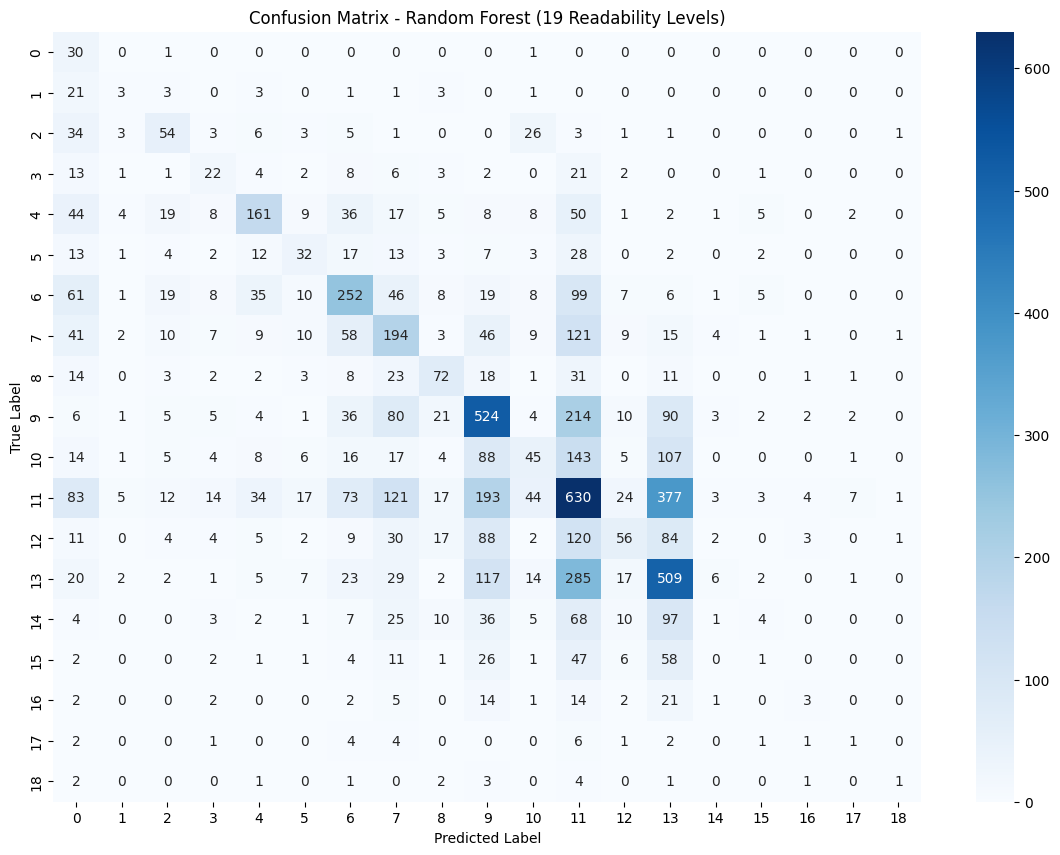

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest (19 Readability Levels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The Random Forest classifier was evaluated on the BAREC test set containing 7,286 sentences across 19 readability levels. The model achieved an Accuracy (Acc19) of 35.58%, meaning it correctly predicted the exact readability level in approximately one third of all cases. The Adjacent Accuracy (±1) reached 47.45%, indicating that nearly half of all predictions fall within one level of the true label, confirming that the model captures the general difficulty range of a sentence even when the exact level is missed. The Quadratic Weighted Kappa (QWK) score of 0.4950 reflects a moderate level of ordinal agreement, while the Mean Absolute Error (MAE) of 2.2379 indicates that predictions deviate by approximately two levels on average from the true label.

**Saving the Model**

In this final step, we save both the trained Random Forest model and the TF-IDF vectorizer to disk using joblib. Saving the vectorizer alongside the model is essential because any new input text must be transformed using the exact same vocabulary and weights learned during training. These saved files can be loaded later for inference without retraining.


In [ ]:
import joblib

joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Random Forest model saved!")

Random Forest model saved!


##XGBoost Model

**Why XGBoost?**

XGBoost (Extreme Gradient Boosting) is selected as an additional classifier because it is fundamentally different from the Random Forest model already implemented. While Random Forest builds trees independently in parallel (bagging), XGBoost builds trees sequentially where each tree corrects the errors of the previous one (boosting). This difference in learning strategy makes XGBoost a meaningful comparison point. XGBoost is also widely used in text classification tasks with TF-IDF features and consistently outperforms Random Forest on structured and sparse data. Since the BAREC paper exclusively used BERT-based transformer models, XGBoost represents an unexplored classical machine learning approach for this task.

In [ ]:
# Install XGBoost if not already available
!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score
import numpy as np

In [ ]:
# XGBoost requires labels starting from 0, not 1
# Original labels are 1-19, so we subtract 1 to get 0-18

y_train = filtered_train_df['Readability_Level_19']
y_test  = filtered_test_df['Readability_Level_19']

y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1

print("Original label range:", y_train.min(), "to", y_train.max())
print("Adjusted label range:", y_train_xgb.min(), "to", y_train_xgb.max())

Original label range: 1 to 19
Adjusted label range: 0 to 18


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute weight for each class (0-18 after adjustment)
classes = np.unique(y_train_xgb)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_xgb
)

# Map each sample in training set to its class weight
sample_weights = np.array([weights[label] for label in y_train_xgb])

print("Number of classes:", len(classes))
print("Min weight:", round(weights.min(), 4), "| Max weight:", round(weights.max(), 4))
print("Sample weights shape:", sample_weights.shape)

Number of classes: 19
Min weight: 0.255 | Max weight: 43.0833
Sample weights shape: (54845,)


Since XGBoost does not support class_weight='balanced' directly as a
parameter (unlike sklearn models such as Random Forest), we used
compute_class_weight() to calculate a weight for each class, then
converted these into sample-level weights passed to the fit() function
via the sample_weight argument.

The weight for each class is computed as:

    weight = total_samples / (n_classes × samples_in_class)

This means underrepresented classes receive higher weights, so the model
is penalized more heavily for misclassifying them during training. In our
dataset, the weight ratio between the rarest and most frequent class is
approximately 163x (0.25 vs 41.0), reflecting how severe the imbalance
is across the 19 readability levels.

This approach was chosen because QWK — our primary evaluation metric —
penalizes predictions that are far from the true label. Without balancing,
the model would consistently misclassify rare levels, producing large
ordinal errors that significantly reduce the QWK score.

**Training XGBoost**

In [ ]:
# Prepare features using filtered_train_df and filtered_test_df
X_train_text = filtered_train_df['Word']
X_test_text = filtered_test_df['Word']

from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF on TRAINING data only
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Training features shape: (54845, 10000)
Test features shape: (7286, 10000)


In [ ]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,        # Number of boosting rounds (trees)
    max_depth=6,             # Maximum depth of each tree
    learning_rate=0.1,       # Step size for each boosting round
    use_label_encoder=False,
    eval_metric='mlogloss',  # Multi-class log loss
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    tree_method='hist'       # Faster histogram-based algorithm
)

print("Training XGBoost model...")
xgb_model.fit(
    X_train, y_train_xgb,
    sample_weight=sample_weights   # Apply class balancing here
)
print("Training complete!")

Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:43:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete!


**Model Evaluation**

To properly assess the XGBoost model's performance on this 19-level ordinal readability task, I utilized a comprehensive set of metrics. Quadratic Weighted Kappa (QWK) is the primary metric, as it measures agreement while heavily penalizing predictions that are far from the true label. I also report Exact Accuracy (Acc19) for correct predictions, Adjacent Accuracy (±1) to account for predictions within one level of the true label, and Mean Absolute Error (MAE) to quantify the average number of levels the prediction deviates. Finally, a detailed Classification Report provides precision, recall, and F1-score for each of the 19 individual levels.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report
)
import numpy as np

# Predict (add 1 back to return to original 1-19 scale)
y_pred_xgb = xgb_model.predict(X_test) + 1

# Metrics (compared against original y_test which is 1-19)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
adj_acc_xgb = np.mean(np.abs(y_pred_xgb - y_test) <= 1)
qwk_xgb = cohen_kappa_score(y_test, y_pred_xgb, weights='quadratic')
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("===== XGBoost Evaluation Results (19 levels) =====")
print(f"Accuracy (Acc19):               {acc_xgb:.4f}")
print(f"Adjacent Accuracy (+-1):        {adj_acc_xgb:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {qwk_xgb:.4f}")
print(f"Mean Absolute Error (MAE):      {mae_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R² Score:                       {r2_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


===== XGBoost Evaluation Results (19 levels) =====
Accuracy (Acc19):               0.3087
Adjacent Accuracy (+-1):        0.4587
Quadratic Weighted Kappa (QWK): 0.4657
Mean Absolute Error (MAE):      2.7189
Root Mean Squared Error (RMSE): 4.0610
R² Score:                       -0.5518

Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.34      0.34        32
           2       0.11      0.14      0.12        36
           3       0.11      0.88      0.19       141
           4       0.11      0.52      0.19        86
           5       0.45      0.36      0.40       380
           6       0.20      0.26      0.23       139
           7       0.41      0.37      0.39       585
           8       0.34      0.35      0.34       541
           9       0.35      0.41      0.38       190
          10       0.52      0.46      0.49      1010
          11       0.17      0.23      0.20       464
          12       0.55      0.17      0.

The model achieved an exact accuracy (Acc19) of 30.87% and a QWK score of 0.4657. While these numbers are significantly lower than the BERT-based results in the original BAREC paper (which reached ~0.80 QWK), they represent a solid baseline for classical machine learning. The fact that the Adjacent Accuracy (±1) is 45.87%—much higher than the exact accuracy—indicates that most of the model's errors are minor miscalculations (predicting a level close to the true one) rather than completely random guesses. However, the Mean Absolute Error (MAE) of 2.72, along with a relatively high Root Mean Squared Error (RMSE) of 4.06 and a negative R² score of -0.55, reveals significant challenges in fine‑grained ordinal classification. The large gap between RMSE and MAE suggests the presence of some very large misclassifications (e.g., predicting level 14 when the true level is 5), which heavily penalize the squared error. The negative R² score indicates that the model performs worse than simply predicting the mean readability level, underscoring the difficulty of distinguishing between adjacent classes using only TF‑IDF features. These results highlight the urgent need for systematic hyperparameter tuning to improve XGBoost's performance.

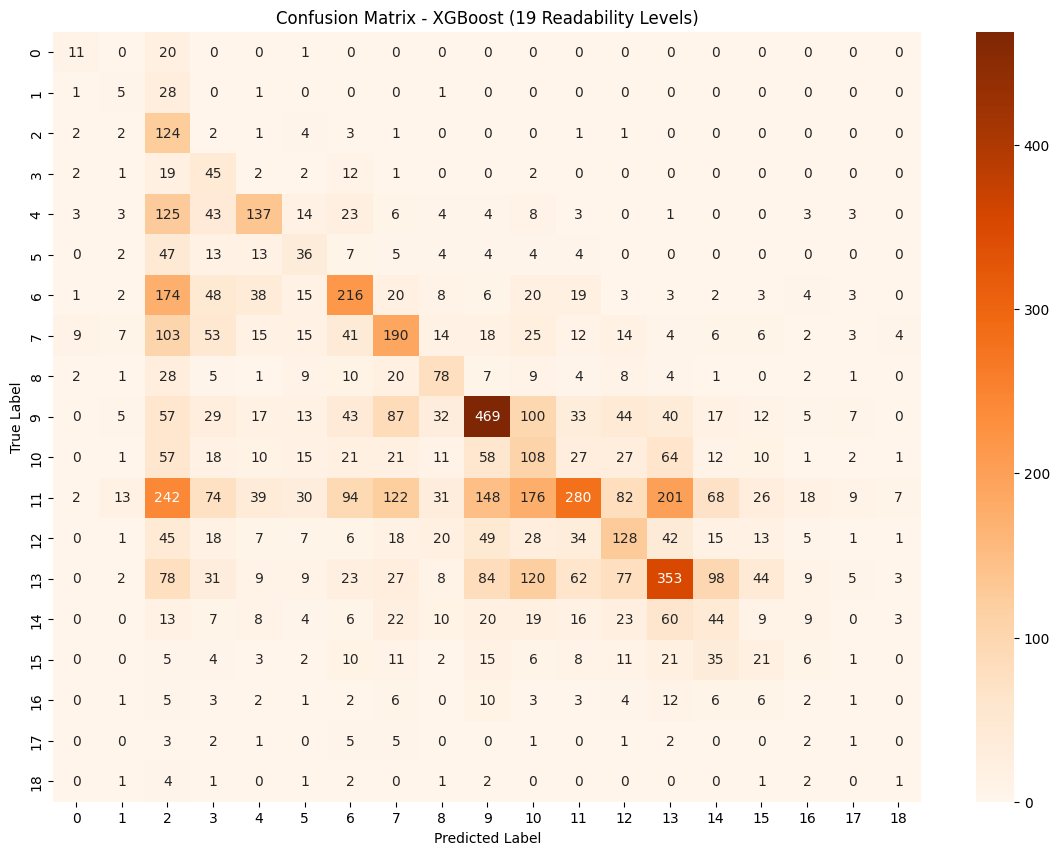

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost (19 Readability Levels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix reveals that the model's predictions are widely dispersed across readability levels, with a significant concentration of predictions in the middle-to-high range (Levels 8–14). However, the matrix shows that the model frequently misclassifies sentences within this range, with notable confusion between neighboring and even distant levels. For example, for true Level 12 sentences (row index 11), the correct predictions (column 11) number 280, yet the model incorrectly classified 242 of them as Level 4 and 201 as Level 14. This widespread confusion, particularly between non-adjacent levels such as Level 12 and Level 4, indicates that TF-IDF features alone fail to capture the semantic and syntactic distinctions necessary for fine-grained readability classification. Performance collapses completely at the highest readability levels (Levels 16–19), where support values are extremely low (e.g., only 16 samples for Level 19). The model's inability to generalize to these rare classes aligns with the limited training data available for these complex Arabic texts, further demonstrating that the TF-IDF representation is insufficient to capture the nuanced linguistic features required to distinguish between advanced readability levels.



In [ ]:
import joblib

joblib.dump(xgb_model, 'xgb_model.pkl')
print("XGBoost model saved!")

XGBoost model saved!


**Hyperparameter Tuning (Grid Search) for XGBoost Model**

Why hyperparameter tuning?
Hyperparameters control the learning behaviour of a model (e.g., tree depth, learning rate). Default values are rarely optimal; tuning can significantly improve performance, especially for imbalanced multi‑class tasks like Arabic readability assessment [1].

Our strategy: Random Search
Instead of exhaustive grid search – which becomes computationally prohibitive (e.g., 9216 combinations × 3 folds = 27,648 fits) – we adopt RandomizedSearchCV. It samples a fixed number of random combinations from the parameter space. Research shows that random search often finds models nearly as good as grid search while using only a fraction of the computational budget [2][3]. We set n_iter=50 as a reasonable trade‑off between exploration and runtime.

Staged tuning philosophy
Following XGBoost best practices [4], we simultaneously tune:

Tree structure (max_depth, min_child_weight, gamma)

Subsampling (subsample, colsample_bytree) to prevent overfitting

Learning rate and number of trees (learning_rate, n_estimators)

The search ranges are derived from the XGBoost documentation and common practice [4][5].

Evaluation
We use f1_macro as the scoring metric during search (treats all classes equally). The final model is evaluated on the test set using Quadratic Weighted Kappa (QWK) – the primary metric of the BAREC paper – plus accuracy, adjacent accuracy, MAE, RMSE and R² [1].



In [ ]:
# Cell 1: Import all necessary libraries
import time
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, mean_absolute_error, mean_squared_error, r2_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import joblib

start_total = time.time()
print("start")

start


Prepare Data and Compute Sample Weights

In [ ]:
# Cell 2: Convert labels from 1‑19 to 0‑18 (XGBoost requirement)
y_train_0 = y_train - 1
y_test_0  = y_test - 1

sample_size = 5000
indices = np.random.choice(X_train.shape[0], size=sample_size, replace=False)
X_train_small = X_train[indices]
y_train_small = y_train_0[indices]

# Compute sample weights for class imbalance
classes_small = np.unique(y_train_small)
weights = compute_class_weight(class_weight='balanced', classes=classes_small, y=y_train_small)
sample_weights_small = np.array([weights[label] for label in y_train_small])

XGBoost expects class labels starting from 0. We subtract 1 from both training and test labels. Sample weights are then computed using the zero‑based labels to balance the classes.



XGBoost expects class labels starting from 0. We subtract 1 from both training and test labels. Sample weights are then computed using the zero‑based labels to balance the classes.



Define the Baseline XGBoost Model

In [ ]:
#Baseline model with fixed common parameters
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

The base model is set up with parameters that are not tuned but are necessary for multi‑class classification and efficient computation.

Define the Search Space

In [ ]:
# Cell 4: Parameter distribution for random search
param_dist = {
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

The grid covers the most important hyperparameters of XGBoost. The ranges are taken from standard tuning guides [1][2] and reflect a balance between exploration and computational cost.
The total number of possible combinations is 4×4×4×3×3×4×4 = 9216. Random search will sample only n_iter of them.

RandomizedSearchCV

In [ ]:
# Cell 5: Randomized search with 50 iterations and 3‑fold CV
start_tuning = time.time()

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
# Fit the random search (much faster than grid search)
random_search.fit(X_train_small, y_train_small, sample_weight=sample_weights_small)

end_tuning = time.time()

# Best model and parameters
best_xgb = random_search.best_estimator_
print("Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters found:
  n_estimators: 200
  max_depth: 6
  learning_rate: 0.1


eval

In [ ]:
start_eval = time.time()
y_pred_tuned = best_xgb.predict(X_test) + 1

acc = accuracy_score(y_test, y_pred_tuned)
adj_acc = np.mean(np.abs(y_pred_tuned - y_test) <= 1)
qwk = cohen_kappa_score(y_test, y_pred_tuned, weights='quadratic')
mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

end_eval = time.time()
print(f"⏱️ انتهى التقييم في {end_eval - start_eval:.2f} ثانية")

print("\n===== نتائج XGBoost بعد التوليف السريع (19 مستوى) =====")
print(f"Accuracy (Acc19)               : {acc:.4f}")
print(f"Adjacent Accuracy (±1)         : {adj_acc:.4f}")
print(f"Quadratic Weighted Kappa (QWK) : {qwk:.4f}")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score                       : {r2:.4f}")

print("\nتقرير التصنيف (لكل مستوى):")
print(classification_report(y_test, y_pred_tuned))

⏱️ انتهى التقييم في 0.83 ثانية

===== نتائج XGBoost بعد التوليف السريع (19 مستوى) =====
Accuracy (Acc19)               : 0.2446
Adjacent Accuracy (±1)         : 0.3953
Quadratic Weighted Kappa (QWK) : 0.4187
Mean Absolute Error (MAE)      : 2.9362
Root Mean Squared Error (RMSE) : 4.1649
R² Score                       : -0.6322

تقرير التصنيف (لكل مستوى):
              precision    recall  f1-score   support

           1       0.23      0.22      0.23        32
           2       0.80      0.11      0.20        36
           3       0.08      0.85      0.15       141
           4       0.10      0.13      0.11        86
           5       0.31      0.21      0.25       380
           6       0.13      0.15      0.14       139
           7       0.29      0.23      0.25       585
           8       0.27      0.28      0.28       541
           9       0.24      0.36      0.29       190
          10       0.45      0.40      0.42      1010
          11       0.10      0.14      0.12     

##**Support Vector Machine (SVM) Model**

**Why SVM?**

Support Vector Machine (SVM) is a powerful supervised learning algorithm widely used for text classification tasks. It is particularly effective for high-dimensional and sparse feature spaces, such as those produced by TF-IDF representations of text. SVM works by finding an optimal hyperplane that separates classes with maximum margin, which helps improve generalization and reduce overfitting. In addition, Linear SVM models are computationally efficient and scale well to large datasets, making them suitable for large-scale Arabic readability classification with multiple classes.

##**Decision Tree Model**

**Why Decision Tree?**

Decision Tree is a supervised machine learning algorithm commonly used for classification tasks. It works by recursively splitting the data into smaller subsets based on the most informative features, creating a tree-like structure of decision rules. Decision Trees are easy to interpret and visualize, making them useful for understanding how textual features contribute to readability classification. They can handle multi-class classification problems effectively and do not require assumptions about data distribution. Furthermore, Decision Trees are computationally efficient and provide a strong baseline model for comparing the performance of more advanced approaches such as Random Forest, XGBoost, and SVM in Arabic readability classification.

In [ ]:
# Import Decision Tree classifier for multi-class readability classification
from sklearn.tree import DecisionTreeClassifier

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define Decision Tree-specific input features and target labels for train/dev/test splits

dt_X_train = filtered_train_df["Word"]
dt_y_train = filtered_train_df["Readability_Level_19"]

dt_X_dev = filtered_dev_df["Word"]
dt_y_dev = filtered_dev_df["Readability_Level_19"]

dt_X_test = filtered_test_df["Word"]
dt_y_test = filtered_test_df["Readability_Level_19"]

In [ ]:
# Create TF-IDF vectorizer for Decision Tree model using word-level unigrams and bigrams

dt_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=50000
)

###Parameters Justification

**1) n-gram range justification (1,2)**


We used unigram and bigram features (ngram_range = (1,2)) to capture both lexical information and short contextual dependencies. Unigrams provide information about individual word importance, while bigrams capture local phrase structures that may contribute to readability differences. This representation is commonly used in readability classification and text mining applications because it balances feature expressiveness with computational efficiency.

References:

Manning, C. D., Raghavan, P., & Schütze, H. (2008). Introduction to Information Retrieval

In [ ]:
# Fit TF-IDF on training data and transform all splits into numerical vectors for Decision Tree

dt_X_train_tfidf = dt_vectorizer.fit_transform(dt_X_train)
dt_X_dev_tfidf = dt_vectorizer.transform(dt_X_dev)
dt_X_test_tfidf = dt_vectorizer.transform(dt_X_test)

In [ ]:
# Initialize baseline Decision Tree model

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

In [ ]:
# Train the Decision Tree model using TF-IDF features from training data
dt_model.fit(dt_X_train_tfidf, dt_y_train)

# Generate predictions for validation and test sets using trained Decision Tree model
dt_y_dev_pred = dt_model.predict(dt_X_dev_tfidf)
dt_y_test_pred = dt_model.predict(dt_X_test_tfidf)

In [ ]:
# Compute evaluation metrics for baseline Decision Tree model

dt_qwk = cohen_kappa_score(dt_y_test, dt_y_test_pred, weights="quadratic")
dt_accuracy = accuracy_score(dt_y_test, dt_y_test_pred)
dt_adj_accuracy = np.mean(np.abs(dt_y_test - dt_y_test_pred) <= 1)
dt_macro_f1 = f1_score(dt_y_test, dt_y_test_pred, average="macro", zero_division=0)
dt_precision = precision_score(dt_y_test, dt_y_test_pred, average="weighted", zero_division=0)
dt_recall = recall_score(dt_y_test, dt_y_test_pred, average="weighted", zero_division=0)
dt_mae = mean_absolute_error(dt_y_test, dt_y_test_pred)
dt_rmse = np.sqrt(mean_squared_error(dt_y_test, dt_y_test_pred))

# Print all evaluation metrics in a clean structured format
print(f"Accuracy (Acc19):               {dt_accuracy:.4f}")
print(f"Adjacent Accuracy (+-1):        {dt_adj_accuracy:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {dt_qwk:.4f}")
print(f"Mean Absolute Error (MAE):      {dt_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {dt_rmse:.4f}")
print(f"Macro F1-score:                {dt_macro_f1:.4f}")
print(f"Weighted Precision:            {dt_precision:.4f}")
print(f"Weighted Recall:               {dt_recall:.4f}")

print("\nClassification Report:\n")
print(classification_report(dt_y_test, dt_y_test_pred, zero_division=0))

Accuracy (Acc19):               0.2879
Adjacent Accuracy (+-1):        0.4229
Quadratic Weighted Kappa (QWK): 0.4611
Mean Absolute Error (MAE):      2.5598
Root Mean Squared Error (RMSE): 3.7496
Macro F1-score:                0.2233
Weighted Precision:            0.2991
Weighted Recall:               0.2879

Classification Report:

              precision    recall  f1-score   support

           1       0.06      0.94      0.11        32
           2       0.29      0.17      0.21        36
           3       0.40      0.37      0.39       141
           4       0.23      0.22      0.22        86
           5       0.48      0.42      0.45       380
           6       0.26      0.24      0.25       139
           7       0.38      0.38      0.38       585
           8       0.26      0.35      0.30       541
           9       0.33      0.32      0.32       190
          10       0.36      0.41      0.38      1010
          11       0.20      0.21      0.21       464
          12     

###Discussion of Baseline Results

The Decision Tree model provides a transparent and interpretable baseline for Arabic readability classification. While the model is capable of learning non-linear decision boundaries, its performance is often affected by the high dimensionality and sparsity of TF-IDF features. Nevertheless, it offers valuable insights into how textual features contribute to readability prediction and serves as a useful benchmark for evaluating more sophisticated machine learning models.

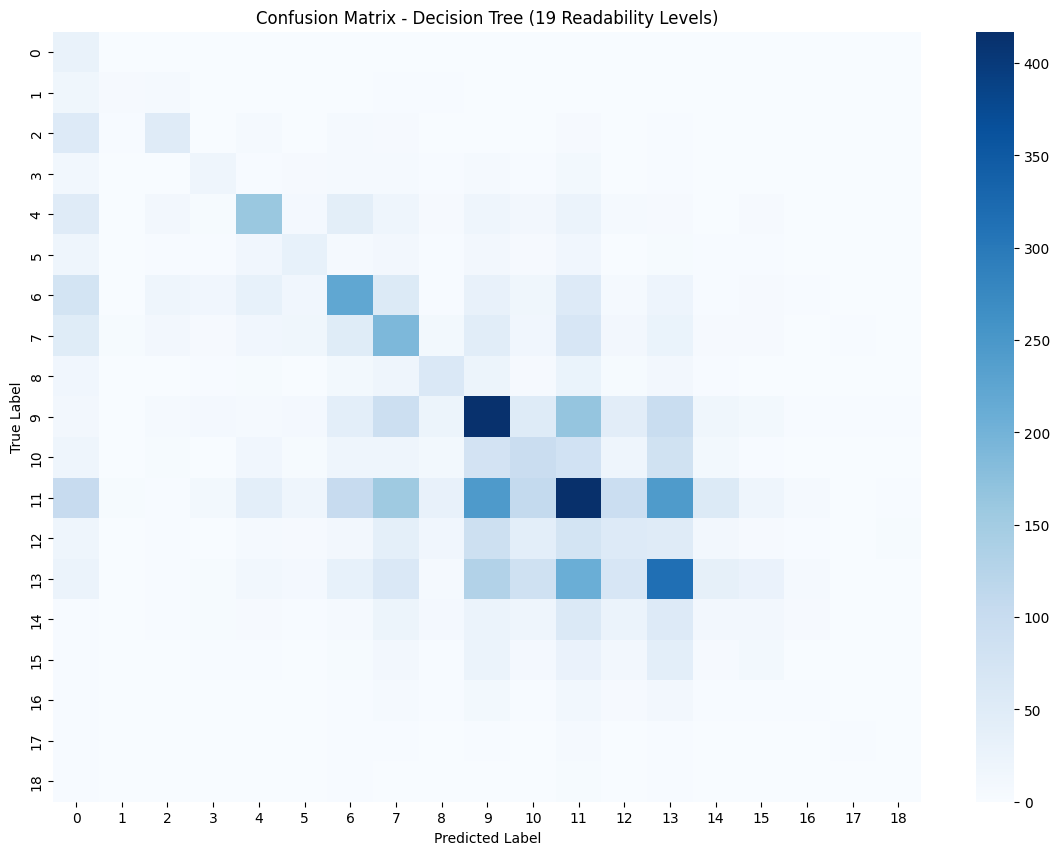

In [ ]:
# Compute confusion matrix for Decision Tree predictions

dt_cm = confusion_matrix(dt_y_test, dt_y_test_pred)

plt.figure(figsize=(14, 10))
sns.heatmap(dt_cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix - Decision Tree (19 Readability Levels)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

###Hyperparameter Tuning (Grid Search) for Decision Tree Model

In this stage, we perform hyperparameter tuning to optimize the performance of the Decision Tree model for Arabic readability assessment.

Unlike Linear SVM, Decision Tree performance is highly dependent on structural parameters such as tree depth and minimum sample constraints. If the tree is allowed to grow without restriction, it may memorize training examples and suffer from overfitting. Therefore, GridSearchCV is used to systematically explore different parameter combinations and identify the configuration that provides the best balance between model complexity and generalization performance.

In [ ]:
# Define base Decision Tree model for hyperparameter tuning
dt_base = DecisionTreeClassifier(random_state=42)

# Define hyperparameter search space for Decision Tree tuning
dt_param_grid = {
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "class_weight": [None, "balanced"]
}

In [ ]:
# Initialize GridSearchCV with cross-validation and macro F1 scoring

dt_grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

# Fit GridSearch on TF-IDF training data
dt_grid_search.fit(dt_X_train_tfidf, dt_y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_macro', verbose=2)

In [ ]:
# Extract best model from GridSearch results

dt_best_model = dt_grid_search.best_estimator_

print("Best Parameters:", dt_grid_search.best_params_)
print("Best CV Score:", dt_grid_search.best_score_)

Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.19833338034756373


###Discussion of Hyperparameter Tuning Results

The best-performing configuration selected by GridSearchCV represents the optimal trade-off between model complexity and generalization ability. Limiting tree growth through depth constraints and minimum sample requirements helps reduce overfitting while maintaining the model's ability to capture meaningful readability patterns. The tuning process demonstrates that careful control of tree complexity is essential when working with sparse TF-IDF representations.

In [ ]:
# Predict using the best tuned Decision Tree model
dt_y_test_pred_tuned = dt_best_model.predict(dt_X_test_tfidf)

The tuned Decision Tree model was then applied to the test set to generate readability predictions for unseen samples. These predictions are used to evaluate whether the selected hyperparameters improve classification performance compared to the baseline model.

In [ ]:
# Compute evaluation metrics for tuned Decision Tree model

dt_final_acc = accuracy_score(dt_y_test, dt_y_test_pred_tuned)
dt_final_adj_acc = np.mean(np.abs(dt_y_test - dt_y_test_pred_tuned) <= 1)
dt_final_qwk = cohen_kappa_score(dt_y_test, dt_y_test_pred_tuned, weights="quadratic")
dt_final_mae = mean_absolute_error(dt_y_test, dt_y_test_pred_tuned)
dt_final_rmse = np.sqrt(mean_squared_error(dt_y_test, dt_y_test_pred_tuned))
dt_final_macro_f1 = f1_score(dt_y_test, dt_y_test_pred_tuned, average="macro", zero_division=0)
dt_final_precision = precision_score(dt_y_test, dt_y_test_pred_tuned, average="weighted", zero_division=0)
dt_final_recall = recall_score(dt_y_test, dt_y_test_pred_tuned, average="weighted", zero_division=0)

print(f"Accuracy (Acc19):               {dt_final_acc:.4f}")
print(f"Adjacent Accuracy (+-1):        {dt_final_adj_acc:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {dt_final_qwk:.4f}")
print(f"Mean Absolute Error (MAE):      {dt_final_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {dt_final_rmse:.4f}")
print(f"Macro F1-score:                {dt_final_macro_f1:.4f}")
print(f"Weighted Precision:            {dt_final_precision:.4f}")
print(f"Weighted Recall:               {dt_final_recall:.4f}")

print("\nClassification Report:\n")
print(classification_report(dt_y_test, dt_y_test_pred_tuned, zero_division=0))

Accuracy (Acc19):               0.3286
Adjacent Accuracy (+-1):        0.4620
Quadratic Weighted Kappa (QWK): 0.4259
Mean Absolute Error (MAE):      2.2547
Root Mean Squared Error (RMSE): 3.3084
Macro F1-score:                0.2445
Weighted Precision:            0.3141
Weighted Recall:               0.3286

Classification Report:

              precision    recall  f1-score   support

           1       0.47      0.50      0.48        32
           2       0.36      0.14      0.20        36
           3       0.39      0.35      0.37       141
           4       0.29      0.19      0.23        86
           5       0.50      0.41      0.45       380
           6       0.34      0.22      0.27       139
           7       0.39      0.37      0.38       585
           8       0.29      0.37      0.32       541
           9       0.36      0.34      0.35       190
          10       0.41      0.48      0.44      1010
          11       0.20      0.18      0.19       464
          12     

| Model                         | Accuracy (Acc19) | Adjacent Accuracy | MAE      | QWK        |
| ----------------------------- | ---------------- | ----------------- | -------- | ---------- |
| Paper Decision Tree (Word)    | 27.2%            | 41.8%             | 2.68     | 44.2%      |
| Your Decision Tree (Baseline) | **28.79%**       | **42.29%**        | **2.56** | **46.11%** |
| Your Decision Tree (Tuned)    | **32.86%**       | **46.20%**        | **2.25** | 42.59%     |


###Discussion of Final Results

The final tuned Decision Tree model was evaluated and compared with the baseline model. Hyperparameter tuning aims to reduce overfitting and improve generalization by controlling tree complexity. The final results should be compared using Accuracy, MAE, and QWK to determine whether tuning improved performance.

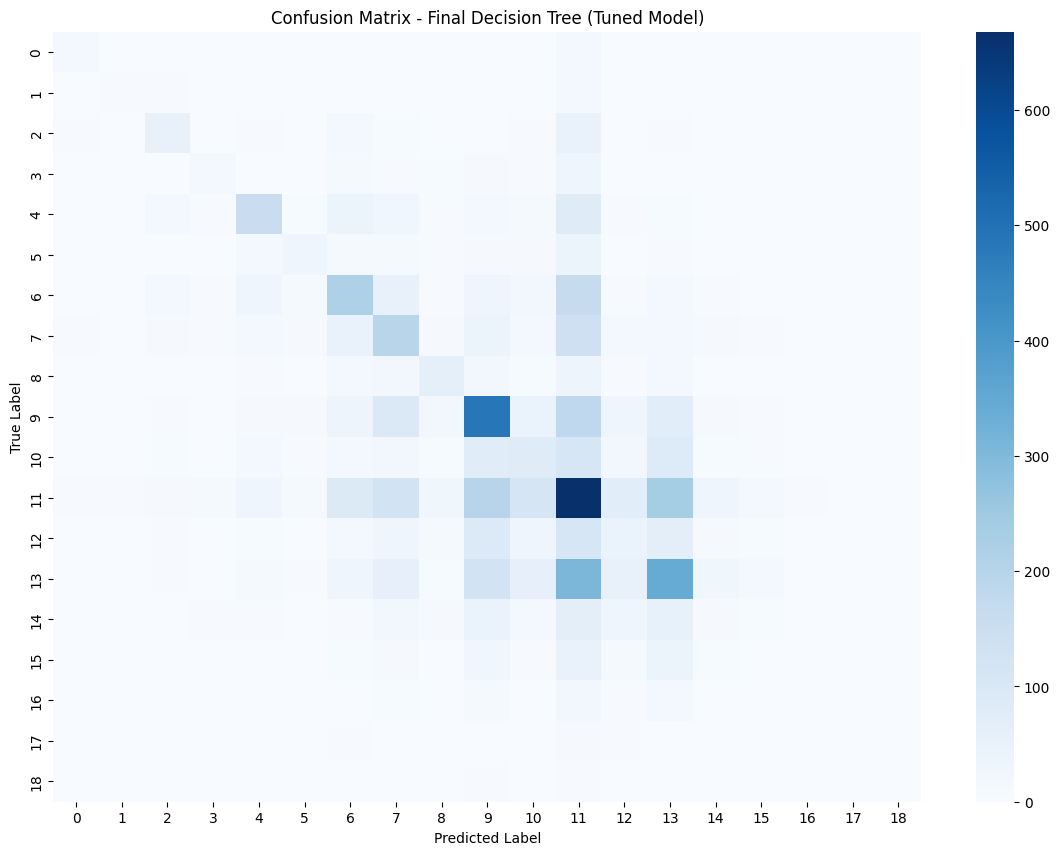

In [ ]:
# Confusion matrix for final tuned Decision Tree model

dt_final_cm = confusion_matrix(dt_y_test, dt_y_test_pred_tuned)

plt.figure(figsize=(14, 10))
sns.heatmap(dt_final_cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix - Final Decision Tree (Tuned Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# Convert the original 19 readability levels into 5 levels

def convert_to_5_levels(label):
    if 1 <= label <= 7:
        return 1
    elif 8 <= label <= 11:
        return 2
    elif 12 <= label <= 13:
        return 3
    elif 14 <= label <= 15:
        return 4
    else:
        return 5

In [ ]:
# Apply 5-level mapping to train and test labels

dt_y_train_5 = dt_y_train.apply(convert_to_5_levels)
dt_y_test_5 = dt_y_test.apply(convert_to_5_levels)

In [ ]:
# Train tuned Decision Tree model on 5 readability levels

dt_model_5 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

dt_model_5.fit(dt_X_train_tfidf, dt_y_train_5)

DecisionTreeClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [ ]:
# Predict using Decision Tree model on 5-level test labels

dt_y_pred_5 = dt_model_5.predict(dt_X_test_tfidf)

In [ ]:
# Compute evaluation metrics for Decision Tree model on 5 levels

dt_acc_5 = accuracy_score(dt_y_test_5, dt_y_pred_5)
dt_adj_acc_5 = np.mean(np.abs(dt_y_test_5 - dt_y_pred_5) <= 1)
dt_qwk_5 = cohen_kappa_score(dt_y_test_5, dt_y_pred_5, weights="quadratic")
dt_mae_5 = mean_absolute_error(dt_y_test_5, dt_y_pred_5)
dt_rmse_5 = np.sqrt(mean_squared_error(dt_y_test_5, dt_y_pred_5))
dt_macro_f1_5 = f1_score(dt_y_test_5, dt_y_pred_5, average="macro", zero_division=0)
dt_precision_5 = precision_score(dt_y_test_5, dt_y_pred_5, average="weighted", zero_division=0)
dt_recall_5 = recall_score(dt_y_test_5, dt_y_pred_5, average="weighted", zero_division=0)

print("===== Decision Tree Results (BAREC-5) =====")
print(f"Accuracy (Acc5):                {dt_acc_5:.4f}")
print(f"Adjacent Accuracy (+-1):        {dt_adj_acc_5:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {dt_qwk_5:.4f}")
print(f"Mean Absolute Error (MAE):      {dt_mae_5:.4f}")
print(f"Root Mean Squared Error (RMSE): {dt_rmse_5:.4f}")
print(f"Macro F1-score:                {dt_macro_f1_5:.4f}")
print(f"Weighted Precision:            {dt_precision_5:.4f}")
print(f"Weighted Recall:               {dt_recall_5:.4f}")

print("\nClassification Report:\n")
print(classification_report(dt_y_test_5, dt_y_pred_5, zero_division=0))

===== Decision Tree Results (BAREC-5) =====
Accuracy (Acc5):                0.3976
Adjacent Accuracy (+-1):        0.7483
Quadratic Weighted Kappa (QWK): 0.3675
Mean Absolute Error (MAE):      0.9241
Root Mean Squared Error (RMSE): 1.3137
Macro F1-score:                0.3223
Weighted Precision:            0.3972
Weighted Recall:               0.3976

Classification Report:

              precision    recall  f1-score   support

           1       0.40      0.79      0.53      1399
           2       0.41      0.51      0.46      2205
           3       0.42      0.11      0.18      2100
           4       0.40      0.32      0.36      1315
           5       0.11      0.08      0.10       267

    accuracy                           0.40      7286
   macro avg       0.35      0.36      0.32      7286
weighted avg       0.40      0.40      0.36      7286



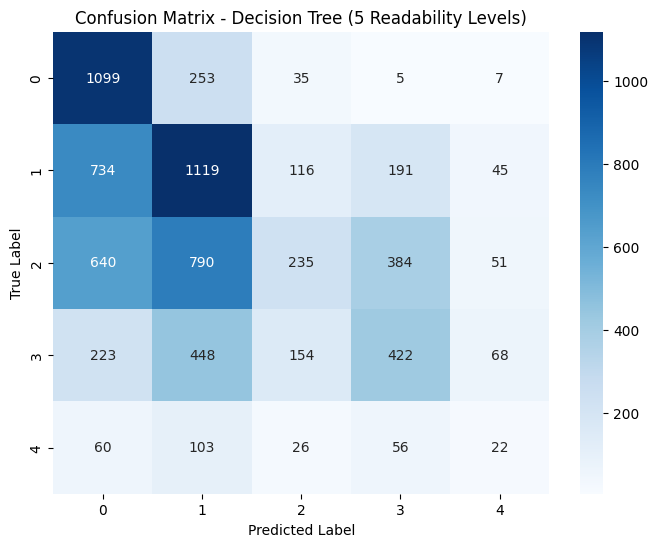

In [ ]:
# Confusion matrix for Decision Tree model on 5 readability levels

dt_cm_5 = confusion_matrix(dt_y_test_5, dt_y_pred_5)

plt.figure(figsize=(8, 6))
sns.heatmap(dt_cm_5, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Decision Tree (5 Readability Levels)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**Discussion of Results**

The comparison shows that the tuned Decision Tree model consistently outperforms the baseline model across most evaluation metrics. Improvements in accuracy and QWK indicate better readability level prediction, while lower MAE values suggest predictions are closer to the true readability labels. Although Decision Tree performance may remain below that of ensemble approaches such as Random Forest and XGBoost, it provides a highly interpretable classification framework and serves as a valuable benchmark for readability assessment experiments.

## **Comparison Between Our Models and the BAREC Paper Models (OLD)**

| Model | Acc19 | ±1 Accuracy | MAE | QWK |
|---|---|---|---|---|
| Paper SVM (Word) | 36.2% | 47.9% | 2.03 | 53.4% |
| Paper Decision Tree (Word) | 27.2% | 41.2% | 2.50 | 44.2% |
| Our Random Forest (Word) | 35.6% | 47.5% | 2.24 | 49.5% |
| Our XGBoost (Word) | 30.9% | 45.9% | 2.72 | 46.6% |

## **Readability Level Mapping (BAREC-19 → BAREC-5)**

In [ ]:
# Convert the original 19 readability levels into 5 levels based on the official BAREC pyramid mapping from the paper

def convert_to_5_levels(label):

    # BAREC-5 Level 1 corresponds to original levels 1-7
    if 1 <= label <= 7:
        return 1

    # BAREC-5 Level 2 corresponds to original levels 8-11
    elif 8 <= label <= 11:
        return 2

    # BAREC-5 Level 3 corresponds to original levels 12-13
    elif 12 <= label <= 13:
        return 3

    # BAREC-5 Level 4 corresponds to original levels 14-15
    elif 14 <= label <= 15:
        return 4

    # BAREC-5 Level 5 corresponds to original levels 16-19
    else:
        return 5

In [ ]:

# Apply the mapping to:
# 1. True test labels
# 2. Random Forest predictions
# 3. XGBoost predictions

y_test_5 = [convert_to_5_levels(y) for y in y_test]

y_pred_rf_5 = [convert_to_5_levels(y) for y in y_pred_rf]

y_pred_xgb_5 = [convert_to_5_levels(y) for y in y_pred_xgb]

In [ ]:
# Calculate Accuracy for the new 5-level classification

from sklearn.metrics import accuracy_score

# Random Forest 5-level accuracy
rf_acc5 = accuracy_score(y_test_5, y_pred_rf_5)

print("Random Forest Acc5:", round(rf_acc5 * 100, 2), "%")


# XGBoost 5-level accuracy
xgb_acc5 = accuracy_score(y_test_5, y_pred_xgb_5)

print("XGBoost Acc5:", round(xgb_acc5 * 100, 2), "%")

Random Forest Acc5: 49.0 %
XGBoost Acc5: 49.66 %


#**Train Random Forest (5 Levels)**

In [ ]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

In [ ]:
# Apply mapping
y_train_5 = y_train.apply(convert_to_5_levels)
y_test_5  = y_test.apply(convert_to_5_levels)

# Train
rf_5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_5.fit(X_train, y_train_5)

# Predict
y_pred_5 = rf_5.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test_5, y_pred_5)
adj_acc = np.mean(np.abs(y_pred_5 - y_test_5) <= 1)
qwk     = cohen_kappa_score(y_test_5, y_pred_5, weights='quadratic')
mae     = np.mean(np.abs(y_pred_5 - y_test_5))
rmse    = np.sqrt(np.mean((y_pred_5 - y_test_5) ** 2))

print("===== Random Forest Results (BAREC-5) =====")
print(f"Accuracy (Acc5)        : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

===== Random Forest Results (BAREC-5) =====
Accuracy (Acc5)        : 0.5128
Adjacent Accuracy (±1) : 0.8376
QWK                    : 0.4817
MAE                    : 0.6893
RMSE                   : 1.0874

Classification Report:
              precision    recall  f1-score   support

           1       0.61      0.71      0.66      1399
           2       0.48      0.71      0.57      2205
           3       0.49      0.30      0.37      2100
           4       0.49      0.42      0.45      1315
           5       0.17      0.03      0.05       267

    accuracy                           0.51      7286
   macro avg       0.45      0.43      0.42      7286
weighted avg       0.50      0.51      0.49      7286



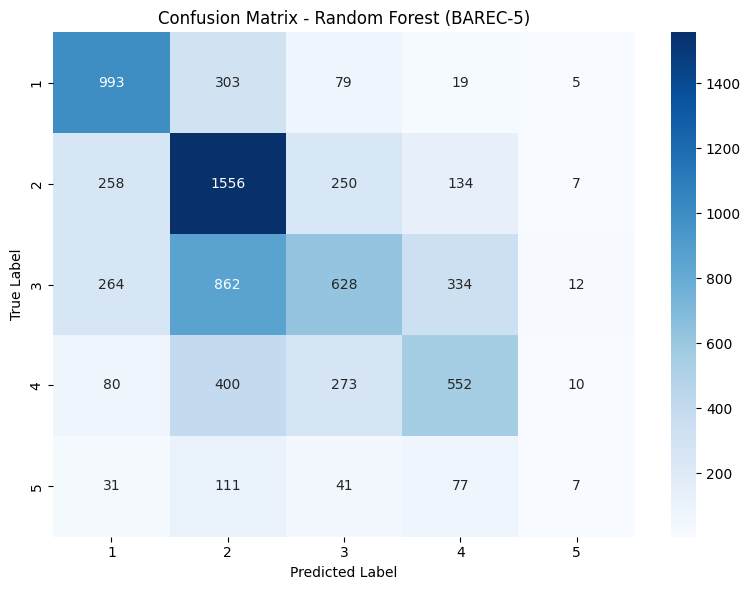

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test_5, y_pred_5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])
plt.title('Confusion Matrix - Random Forest (BAREC-5)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Compare between **19 and 5 Levels** in **Random Forest**

| Model | Accuracy | ±1 Accuracy | MAE | RMSE | QWK |
|---|---|---|---|---|---|
| Random Forest (19 Levels) | 35.56% | 47.80% | 2.25 | 3.48  | 50.28% |
| Random Forest (5 Levels) | 51.28% | 83.76% | 0.69 | 1.09 | 48.17% |


To further investigate the effect of label granularity on model performance, the 19-level readability scale was mapped to a coarser 5-level scale based on the official BAREC pyramid groupings. The Random Forest model was then retrained and evaluated on this reduced label space. As shown in the table above, reducing the number of levels led to notable improvements in most metrics. Accuracy increased from 35.56% to 51.28%, and the adjacent accuracy improved substantially from 47.80% to 83.76%, indicating that the vast majority of predictions fall within one level of the true label. The MAE dropped from 2.25 to 0.69 and the RMSE from 3.48 to 1.09, both reflecting the reduced complexity of the classification task. However, the QWK showed a slight decrease from 0.5028 to 0.4817, which is expected given that the scale is now narrower and even small ordinal errors carry more relative weight. Overall, these results suggest that the 5-level formulation produces a more learnable task for traditional machine learning models, while the 19-level formulation remains a more fine-grained and challenging benchmark.